<a href="https://colab.research.google.com/github/garganupam/ML/blob/main/ML2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import sklearn
import scipy
warnings.filterwarnings('ignore')

In [54]:
df=pd.read_csv('heart.csv')

EDA

In [107]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110.0,264.0,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144.0,193.0,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130.0,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130.0,236.0,0,LVH,174,N,0.0,Flat,1


In [108]:
df.shape

(918, 12)

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    float64
 4   Cholesterol     918 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 86.2+ KB


In [110]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.540893,244.636253,0.233115,136.809368,0.887364,0.553377
std,9.432617,17.989932,53.318029,0.423046,25.460334,1.066570,0.497414
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,244.640000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [111]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [112]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

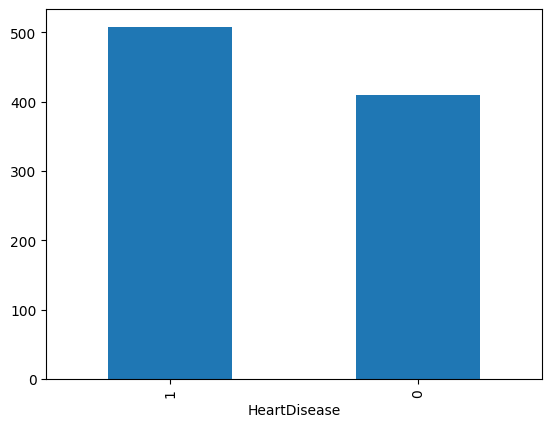

In [113]:
df['HeartDisease'].value_counts().plot(kind="bar")

Means data is equally distributed otherewise we need to make data equally distributed by data augmentation

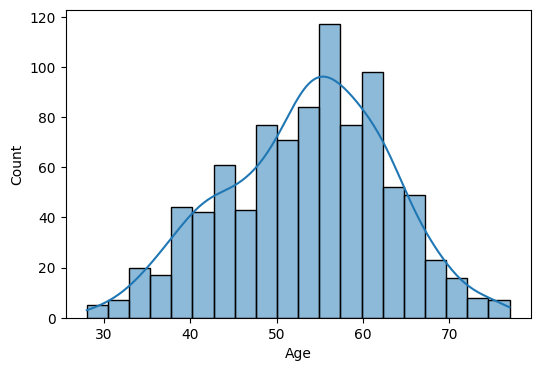

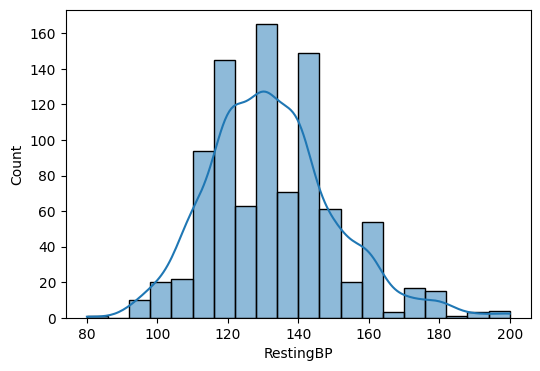

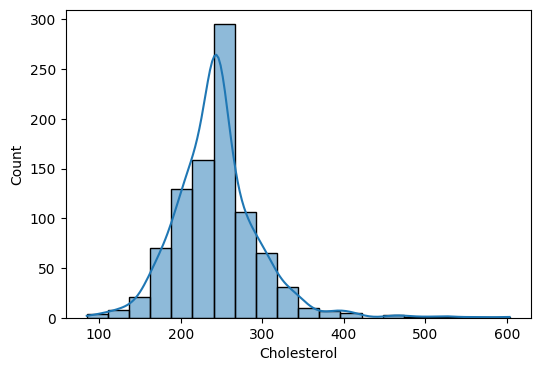

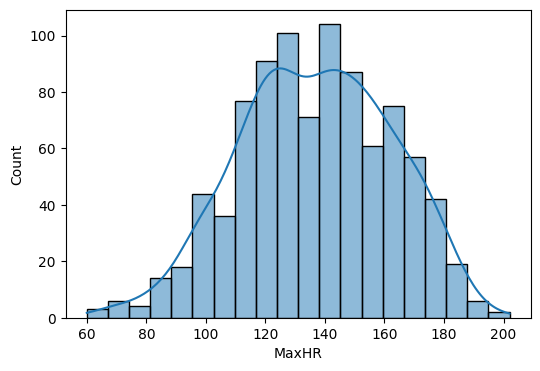

In [114]:
numeric_columns=['Age','RestingBP','Cholesterol','MaxHR']
for col in numeric_columns:
  plt.figure(figsize=(6,4))
  sns.histplot(df[col],kde=True,bins=20)

In [63]:
# Now cholestrol seems bit different as a person cant have 0 cholestrol

In [115]:
df['Cholesterol'].value_counts()

,count
Cholesterol,
244.64,172
254.00,11
220.00,10
223.00,10
204.00,9
...,...
353.00,1
278.00,1
157.00,1


In [65]:
# So fill the 0 cholestrol with mean of the normal cholestrol of rest of the people

In [66]:
ch_mean=df.loc[df['Cholesterol'] !=0 , 'Cholesterol'].mean()

In [67]:
ch_mean

np.float64(244.6353887399464)

In [68]:
df['Cholesterol'].replace(0,ch_mean,inplace=True)

In [69]:
df['Cholesterol']=df['Cholesterol'].round(2)

In [116]:
df['Cholesterol'].value_counts()

,count
Cholesterol,
244.64,172
254.00,11
220.00,10
223.00,10
204.00,9
...,...
353.00,1
278.00,1
157.00,1


Resting BP also shows that there is one person having bp=0, so it is also not possible so we will replace it by the mean bp

In [117]:
BP_mean=df.loc[df['RestingBP'] !=0 , 'RestingBP'].mean()

In [118]:
BP_mean

np.float64(132.54089324618738)

In [119]:
df['RestingBP'].replace(0,BP_mean,inplace=True)

In [120]:
df['RestingBP']=df['RestingBP'].round(2)

In [121]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110.0,264.0,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144.0,193.0,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130.0,131.0,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130.0,236.0,0,LVH,174,N,0.0,Flat,1


In [76]:
pip install sheryanalysis==0.1.0


In [77]:
import sheryanalysis as sh
sh.analyze(df)


🔍 Basic Analysis Report


INFO:sheryanalysis:
🔍 Basic Analysis Report


------------------------------------------------------------


INFO:sheryanalysis:------------------------------------------------------------


📏 Shape: (918, 12)


...


🔠 Categorical Columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']


INFO:sheryanalysis:
🔠 Categorical Columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']



🔢 Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


INFO:sheryanalysis:
🔢 Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


{'shape': (918, 12),
 'columns': ['Age',
  'Sex',
  'ChestPainType',
  'RestingBP',
  'Cholesterol',
  'FastingBS',
  'RestingECG',
  'MaxHR',
  'ExerciseAngina',
  'Oldpeak',
  'ST_Slope',
  'HeartDisease'],
 'dtypes': {'Age': dtype('int64'),
  'Sex': dtype('O'),
  'ChestPainType': dtype('O'),
  'RestingBP': dtype('float64'),
  'Cholesterol': dtype('float64'),
  'FastingBS': dtype('int64'),
  'RestingECG': dtype('O'),
  'MaxHR': dtype('int64'),
  'ExerciseAngina': dtype('O'),
  'Oldpeak': dtype('float64'),
  'ST_Slope': dtype('O'),
  'HeartDisease': dtype('int64')},
 'null_counts': {'Age': 0,
  'Sex': 0,
  'ChestPainType': 0,
  'RestingBP': 0,
  'Cholesterol': 0,
  'FastingBS': 0,
  'RestingECG': 0,
  'MaxHR': 0,
  'ExerciseAngina': 0,
  'Oldpeak': 0,
  'ST_Slope': 0,
  'HeartDisease': 0},
 'total_rows': 918,
 'column_types': {'categorical': ['Sex',
   'ChestPainType',
   'FastingBS',
   'RestingECG',
   'ExerciseAngina',
   'ST_Slope',
   'HeartDisease'],
  'numerical': ['Age', 'Rest

Now count plots for categorical variables

<Axes: xlabel='Sex', ylabel='count'>

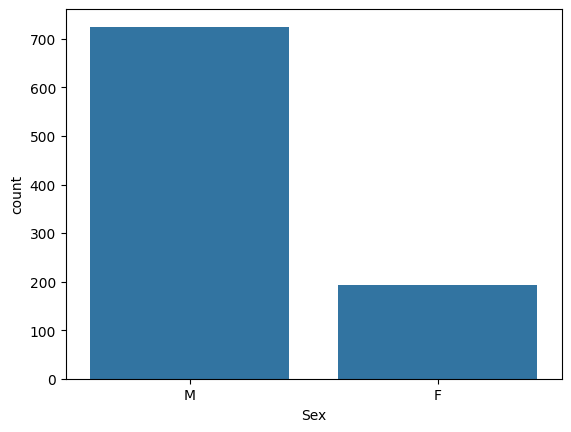

In [78]:
sns.countplot(x=df['Sex'])

<Axes: xlabel='Sex', ylabel='count'>

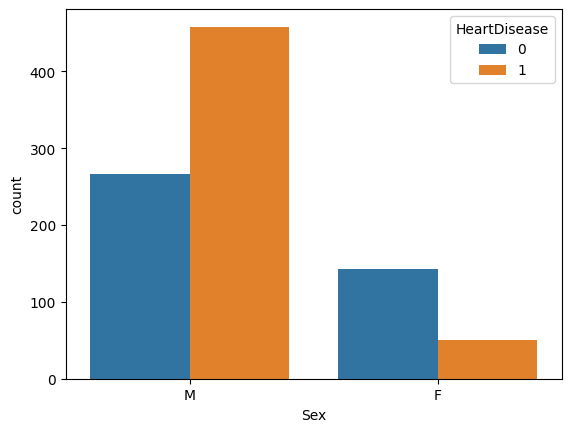

In [79]:
sns.countplot(x=df['Sex'],hue=df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

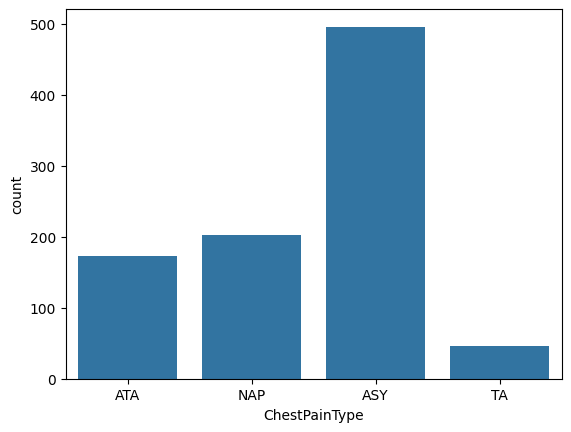

In [80]:
sns.countplot(x=df['ChestPainType'])

<Axes: xlabel='ChestPainType', ylabel='count'>

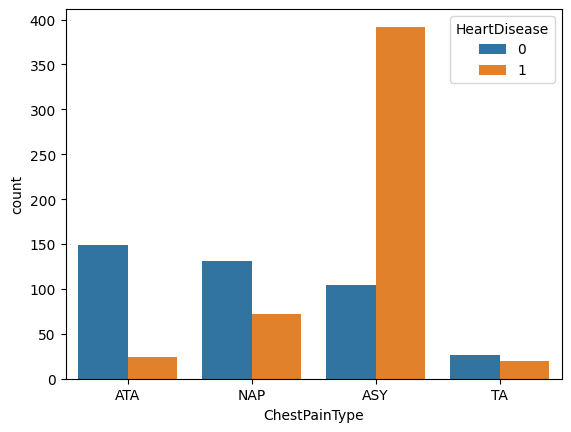

In [81]:
sns.countplot(x=df['ChestPainType'],hue=df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

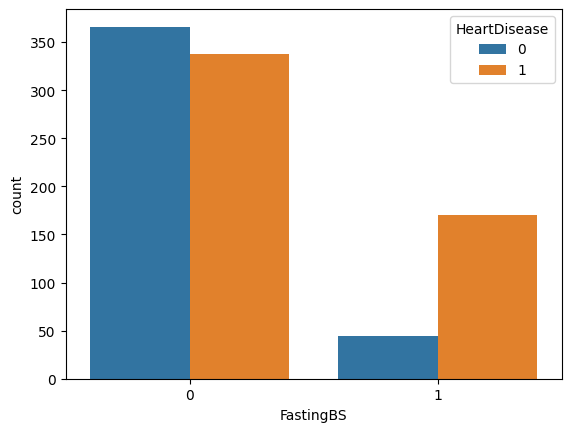

In [82]:
sns.countplot(x=df['FastingBS'],hue=df['HeartDisease'])

Now comparing my numeric variable with my categorical variable (heart disease)

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

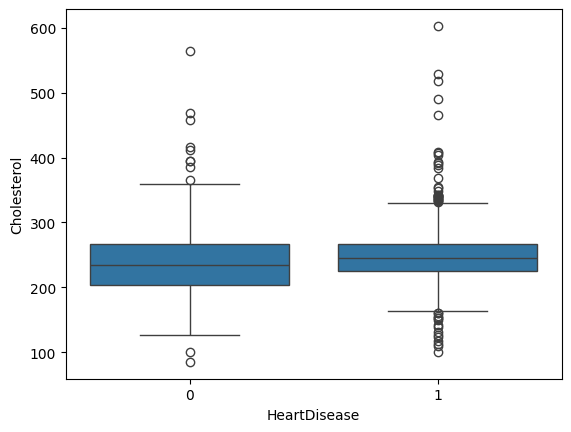

In [122]:
sns.boxplot(x='HeartDisease',y= 'Cholesterol', data=df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

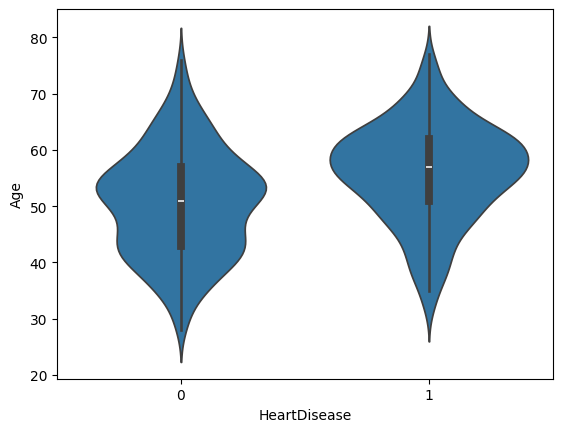

In [123]:
sns.violinplot(x='HeartDisease',y='Age',data=df)

In [85]:
# We can find the correlation with the heatmap

<Axes: >

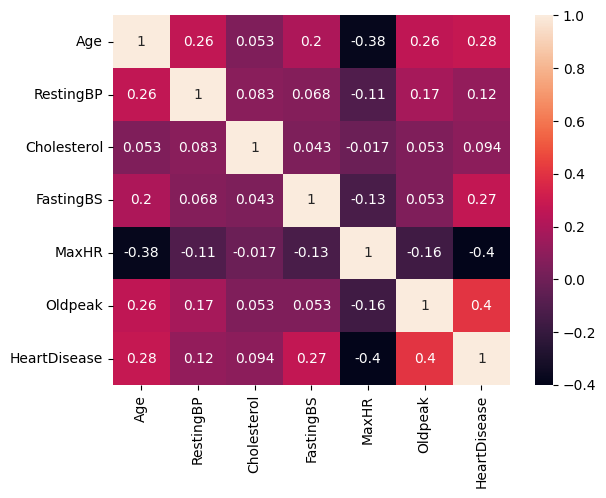

In [124]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

**Data preprocesssing and cleaning // converting all values into numbers**




In [125]:
df_encode=pd.get_dummies(df,drop_first=True)

In [127]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [130]:
df_encode=df_encode.astype(int)

Now we have to do Standard Scaling to put values between -3 and +3

In [131]:
from sklearn.preprocessing import StandardScaler
numeric_cols=['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
scalar=StandardScaler()
df_encode[numeric_cols]=scalar.fit_transform(df_encode[numeric_cols])
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.398662,-0.039684,-0.069751,0,1.535481,-0.383983,0,1,1,0,0,1,0,0,0,1
1,0.045626,1.417516,-1.432128,0,0.016546,-0.383983,1,0,0,1,0,1,0,0,1,0
2,-1.398662,-0.039684,-0.069751,0,-1.502389,-0.383983,0,1,1,0,0,0,1,0,0,1
3,0.045626,-0.039684,-0.069751,0,-1.502389,-0.383983,1,0,0,0,0,1,0,1,1,0
4,0.045626,-0.039684,-0.069751,0,0.016546,-0.383983,0,1,0,1,0,1,0,0,0,1


In [139]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.398662,-0.039684,-0.069751,0,1.535481,-0.383983,0,1,1,0,0,1,0,0,0,1
1,0.045626,1.417516,-1.432128,0,0.016546,-0.383983,1,0,0,1,0,1,0,0,1,0
2,-1.398662,-0.039684,-0.069751,0,-1.502389,-0.383983,0,1,1,0,0,0,1,0,0,1
3,0.045626,-0.039684,-0.069751,0,-1.502389,-0.383983,1,0,0,0,0,1,0,1,1,0
4,0.045626,-0.039684,-0.069751,0,0.016546,-0.383983,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,0.045626,-1.496884,-0.069751,0,0.016546,-0.383983,1,1,0,0,1,1,0,0,1,0
914,1.489913,-0.039684,-0.069751,1,0.016546,3.194665,1,1,0,0,0,1,0,0,1,0
915,0.045626,-0.039684,-2.794504,0,0.016546,-0.383983,1,1,0,0,0,1,0,1,1,0
916,0.045626,-0.039684,-0.069751,0,1.535481,-0.383983,1,0,1,0,0,0,0,0,1,0


In [94]:
# Feature extraction and feature engineering

Think of it this way
Test	Data type	What it asks:

1.Pearson correlation	Numerical ↔ numerical/binary	Is there a linear relationship?

2. Chi-square test	Categorical ↔ categorical	Is there an association between categories?

In [135]:
from scipy.stats import pearsonr

selected_features=[
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak",
    "Sex_M",
    "ChestPainType_ATA",
    "ChestPainType_NAP",
    "ChestPainType_TA",
    "RestingECG_Normal",
    "ExerciseAngina_Y",
    "ST_Slope_Flat",
    "ST_Slope_Up"
]

correlations = {
    feature: pearsonr(df_encode[feature], df_encode['HeartDisease'])[0]
    for feature in selected_features
}

correlation_df=pd.DataFrame(list(correlations.items()),columns=['feature','correlation'])
correlation_df.sort_values(by='correlation',ascending=False)

,feature,correlation
12,ST_Slope_Flat,0.554134
11,ExerciseAngina_Y,0.494282
6,Sex_M,0.305445
3,FastingBS,0.267291
5,Oldpeak,0.250866
0,Age,0.231173
1,RestingBP,0.089932
2,Cholesterol,0.041767
9,ChestPainType_TA,-0.054790
10,RestingECG_Normal,-0.091580


In [136]:
cat_features=[
    "FastingBS",
    "Oldpeak",
    "Sex_M",
    "ChestPainType_NAP",
    "ChestPainType_TA",
    "ChestPainType_ATA",
    "RestingECG_Normal",
    "RestingECG_ST",
    "ExerciseAngina_Y",
    "ST_Slope_Flat",
    "ST_Slope_Up"]

In [140]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha=0.05

chi2_results={}

for col in cat_features:
    contingency = pd.crosstab(df_encode[col], df_encode['HeartDisease'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df=pd.DataFrame(chi2_results).T
chi2_df=chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,Decision
ST_Slope_Up,352.823905,0.0,Reject Null (Keep Feature)
ST_Slope_Flat,279.659914,0.0,Reject Null (Keep Feature)
ExerciseAngina_Y,222.259383,0.0,Reject Null (Keep Feature)
ChestPainType_ATA,146.236323,0.0,Reject Null (Keep Feature)
Sex_M,84.145101,0.0,Reject Null (Keep Feature)
Oldpeak,94.799951,0.0,Reject Null (Keep Feature)
FastingBS,64.320679,0.0,Reject Null (Keep Feature)
ChestPainType_NAP,40.608711,0.0,Reject Null (Keep Feature)
RestingECG_ST,9.135266,0.002507,Reject Null (Keep Feature)
RestingECG_Normal,7.327532,0.006791,Reject Null (Keep Feature)


In [141]:
final_df=df_encode[['Age','Sex_M','FastingBS','RestingBP',"Oldpeak",'ExerciseAngina_Y','ST_Slope_Flat','ST_Slope_Up','ChestPainType_ATA','ChestPainType_NAP','RestingECG_ST','RestingECG_Normal']]

In [142]:
final_df

,Age,Sex_M,FastingBS,RestingBP,Oldpeak,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,ChestPainType_ATA,ChestPainType_NAP,RestingECG_ST,RestingECG_Normal
0,-1.398662,1,0,-0.039684,-0.383983,0,0,1,1,0,0,1
1,0.045626,0,0,1.417516,-0.383983,0,1,0,0,1,0,1
2,-1.398662,1,0,-0.039684,-0.383983,0,0,1,1,0,1,0
3,0.045626,0,0,-0.039684,-0.383983,1,1,0,0,0,0,1
4,0.045626,1,0,-0.039684,-0.383983,0,0,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
913,0.045626,1,0,-1.496884,-0.383983,0,1,0,0,0,0,1
914,1.489913,1,1,-0.039684,3.194665,0,1,0,0,0,0,1
915,0.045626,1,0,-0.039684,-0.383983,1,1,0,0,0,0,1
916,0.045626,0,0,-0.039684,-0.383983,0,1,0,1,0,0,0
